In [70]:
import numpy as np
import matplotlib.pyplot as plt

In [71]:
s = (.3, .4)
def f(x, s=s):
    distance = ((s[0] - x[0])**2 + (s[1]-x[1])**2)**.5
    return np.exp(-100*(distance-.2)**2)

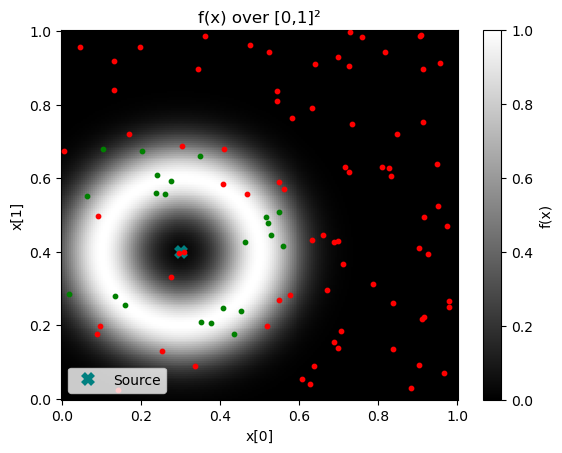

In [72]:
# 100 random points in 2D with corresponding sample value
samplePoints = np.random.uniform(0, 1, (100, 3))

for i in range(100):
    x = samplePoints[i, :2]
    samplePoints[i, 2] = 1 if samplePoints[i, 2] < f(x) else -1

x0 = np.linspace(0, 1, 200)
x1 = np.linspace(0, 1, 200)
X0, X1 = np.meshgrid(x0, x1)
Z = f((X0, X1))

plt.figure()
plt.pcolormesh(X0, X1, Z, shading='auto', cmap='gray')
plt.colorbar(label='f(x)')
plt.plot(s[0], s[1], 'x', color='teal', markersize=7, markeredgewidth=4, label='Source')

points = np.array(samplePoints)
for label, color in [(1, 'green'), (-1, 'red')]:
    mask = points[:, 2] == label
    plt.scatter(points[mask, 0], points[mask, 1], color=color, s=10, zorder=5)

plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.legend()
plt.title('f(x) over [0,1]²')
plt.show()

In [73]:
def p(point, s):
    return f(point, s=s) if point[2] == 1 else 1 - f(point, s=s)

def L(s, points):
    total = 1
    for x in points:
        total *= p(x, s=s)
    return total

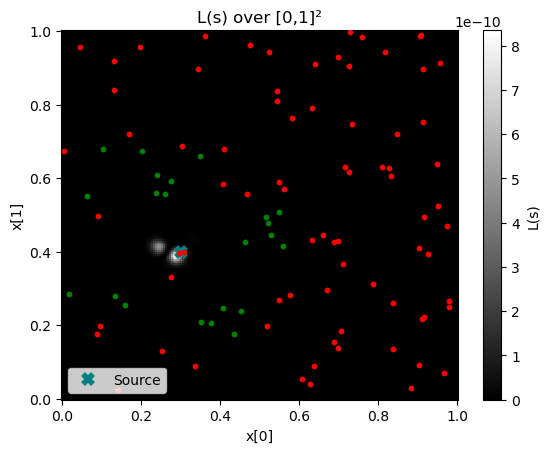

In [74]:
x0 = np.linspace(0, 1, 200)
x1 = np.linspace(0, 1, 200)
X0, X1 = np.meshgrid(x0, x1)
Z = np.vectorize(lambda a, b: L((a, b), samplePoints))(X0, X1)

plt.figure()
plt.pcolormesh(X0, X1, Z, shading='auto', cmap='gray')
plt.colorbar(label='L(s)')
plt.plot(s[0], s[1], 'x', color='teal', markersize=7, markeredgewidth=4, label='Source')

points = np.array(samplePoints)
for label, color in [(1, 'green'), (-1, 'red')]:
    mask = points[:, 2] == label
    plt.scatter(points[mask, 0], points[mask, 1], color=color, s=10, zorder=5)

plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.legend()
plt.title('L(s) over [0,1]²')
plt.show()